In [1]:
!pip install numpy pandas matplotlib scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 156.3 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 154.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 60.8 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 57.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 178.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 36.8 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 183.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 89.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 97.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 160.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 206.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notic

Installing scikit-learn...



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


===== REGRESSION RESULTS =====
Mean Squared Error: 24.92245623377605
R2 Score: 0.8565784063748548


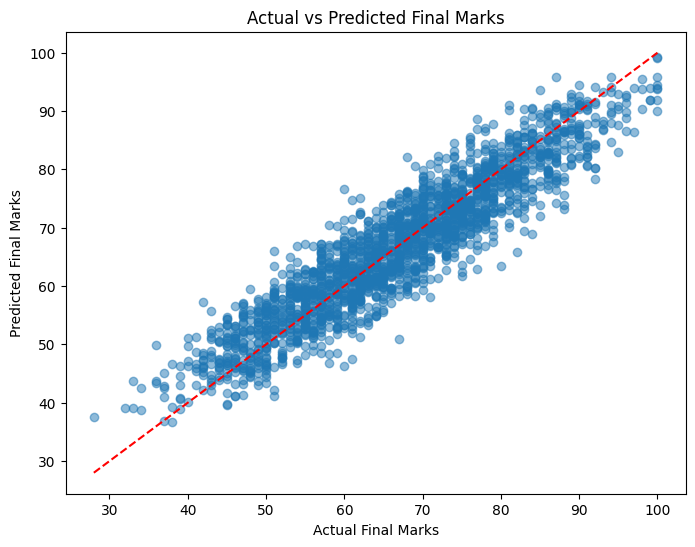


===== CLASSIFICATION RESULTS =====
Accuracy: 0.9015

Classification Report:
              precision    recall  f1-score   support

        Fail       0.85      0.81      0.83       601
        Pass       0.92      0.94      0.93      1399

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix:
[[ 488  113]
 [  84 1315]]


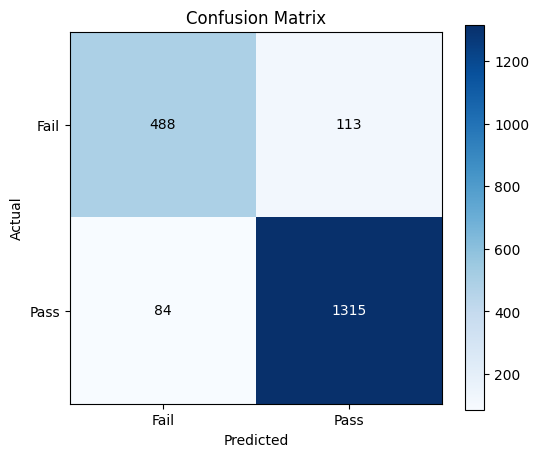

In [4]:
# 1. Automatically install required libraries if missing
import sys
import subprocess

required_libraries = ["pandas", "openpyxl", "matplotlib", "scikit-learn"]
for lib in required_libraries:
    try:
        __import__(lib)
    except ImportError:
        print(f"Installing {lib}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

# 2. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 3. Load dataset from the current local directory (/app)
# Make sure you upload 'student_marks_10000 (1).xlsx' using the JupyterLab file explorer first!
try:
    data = pd.read_excel("student_marks_10000 (1).xlsx")
except FileNotFoundError:
    raise FileNotFoundError(
        "Dataset not found! Please upload 'student_marks_10000 (1).xlsx' "
        "to your JupyterLab left sidebar file browser panel."
    )

# -----------------------------
# REGRESSION: Predict Final Marks
# -----------------------------
X = data[['Study_Hours', 'Attendance', 'Assignment_Score']]
y = data['Final_Marks']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== REGRESSION RESULTS =====")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()


# -----------------------------
# CLASSIFICATION: Pass / Fail
# -----------------------------
X_cls = data[['Study_Hours', 'Attendance', 'Assignment_Score']]
y_cls = data['Result']

# Split data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Train Logistic Regression model
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_cls, y_train_cls)

# Predictions
y_pred_cls = clf_model.predict(X_test_cls)

# Evaluation
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("\n===== CLASSIFICATION RESULTS =====")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_cls))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')  # Added a clean blue color map
plt.colorbar()
plt.xticks([0,1], ['Fail','Pass'])
plt.yticks([0,1], ['Fail','Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.show()
